# Credit Scoring Model
### Predicting Individual Creditworthiness using Classification Algorithms

**Objective:** Predict whether an individual is likely to default on credit, using historical financial data.

**Approach:** Logistic Regression, Decision Tree, and Random Forest classifiers.

**Evaluation Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC.

---

## 1. Imports

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid')
%matplotlib inline

RANDOM_STATE = 42

## 2. Load Dataset

This project ships with a **realistic synthetic dataset** (`../data/credit_data.csv`, 20,000 rows) so it runs end-to-end without needing an external download.
It includes: demographics, income, credit utilization, payment history, loan details, realistic missing values, and a ~26% default rate (imbalanced, like real credit portfolios).

To use your own data, just replace the CSV — as long as it has a binary target column named `default`.

In [2]:
df = pd.read_csv('../data/credit_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (20000, 17)


,age,education,marital_status,employment_type,employment_length_years,annual_income,credit_history_length,num_open_accounts,credit_limit,credit_utilization,existing_debt,num_late_payments_12m,num_credit_inquiries_6m,loan_amount_requested,home_ownership,purpose,default
0,46,high_school,married,self_employed,13.3,27023.77,27,7,16076.89,0.301,12040.27,1,0,8045.72,RENT,debt_consolidation,0
1,38,phd,single,self_employed,8.8,49650.57,16,4,22033.76,0.503,12519.43,0,2,6613.34,OWN,other,0
2,48,masters,married,salaried,9.5,106461.44,26,7,76513.22,0.490,43317.27,4,0,27658.08,MORTGAGE,car,1
3,58,masters,married,salaried,11.2,161383.63,36,11,51625.03,0.349,19642.08,0,1,28821.49,MORTGAGE,debt_consolidation,0
4,37,bachelors,married,self_employed,6.0,50454.02,15,1,32041.77,0.221,16034.48,1,1,17951.00,OWN,medical,0


## 3. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      20000 non-null  int64  
 1   education                20000 non-null  str    
 2   marital_status           20000 non-null  str    
 3   employment_type          20000 non-null  str    
 4   employment_length_years  19600 non-null  float64
 5   annual_income            19200 non-null  float64
 6   credit_history_length    20000 non-null  int64  
 7   num_open_accounts        20000 non-null  int64  
 8   credit_limit             20000 non-null  float64
 9   credit_utilization       20000 non-null  float64
 10  existing_debt            20000 non-null  float64
 11  num_late_payments_12m    20000 non-null  int64  
 12  num_credit_inquiries_6m  20000 non-null  int64  
 13  loan_amount_requested    20000 non-null  float64
 14  home_ownership           20000 no

In [4]:
print('Missing values:')
print(df.isna().sum()[df.isna().sum() > 0])
print()
print('Default rate:', round(df['default'].mean() * 100, 2), '%')

Missing values:
employment_length_years    400
annual_income              800
dtype: int64

Default rate: 26.26 %


C:\Users\DELL\AppData\Local\Temp\ipykernel_18724\3004928060.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Good (0)', 'Default (1)'])


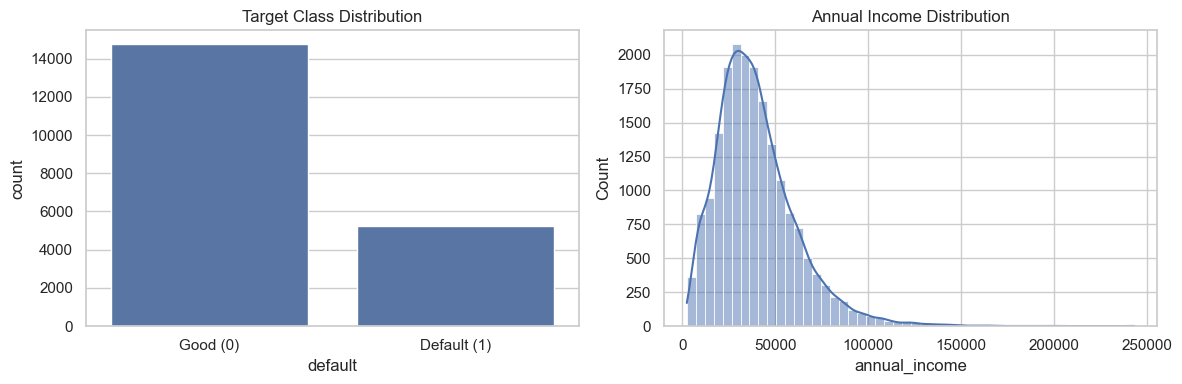

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='default', ax=axes[0])
axes[0].set_title('Target Class Distribution')
axes[0].set_xticklabels(['Good (0)', 'Default (1)'])

sns.histplot(df['annual_income'].dropna(), bins=50, ax=axes[1], kde=True)
axes[1].set_title('Annual Income Distribution')
plt.tight_layout()
plt.show()

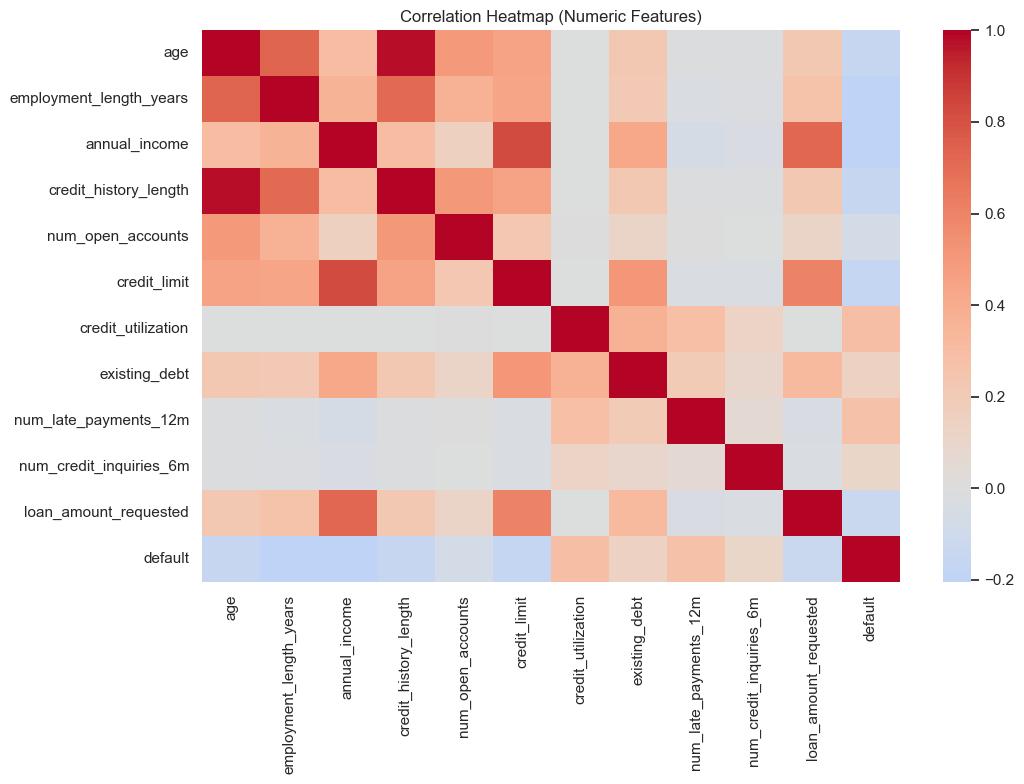

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(11, 8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

## 4. Data Cleaning

`annual_income` and `employment_length_years` contain missing values (real bureau data is never fully clean). We impute them with the median.

In [7]:
for col in ['annual_income', 'employment_length_years']:
    df[col] = SimpleImputer(strategy='median').fit_transform(df[[col]])

assert df.isna().sum().sum() == 0
print('Missing values remaining:', df.isna().sum().sum())

Missing values remaining: 0


## 5. Feature Engineering

We derive a handful of domain-specific ratios that are known to be predictive in credit risk modeling:
- **debt_to_income** — overall debt burden relative to income
- **loan_to_income** — how large the requested loan is relative to income
- **credit_used_amount** — absolute dollar amount of credit currently used
- **income_per_account** — income spread across number of open accounts
- **late_payment_rate** — late payments normalized by credit history length
- **high_risk_combo** — flag for the interaction of high utilization AND recent late payments

Categorical variables (education, marital status, employment type, home ownership, purpose) are one-hot encoded.

In [8]:
def engineer_features(df):
    df = df.copy()
    df['debt_to_income'] = df['existing_debt'] / (df['annual_income'] + 1)
    df['loan_to_income'] = df['loan_amount_requested'] / (df['annual_income'] + 1)
    df['credit_used_amount'] = df['credit_limit'] * df['credit_utilization']
    df['income_per_account'] = df['annual_income'] / (df['num_open_accounts'] + 1)
    df['late_payment_rate'] = df['num_late_payments_12m'] / (df['credit_history_length'] + 1)
    df['high_risk_combo'] = (
        (df['credit_utilization'] > 0.7) & (df['num_late_payments_12m'] > 1)
    ).astype(int)
    df = pd.get_dummies(
        df,
        columns=['education', 'marital_status', 'employment_type', 'home_ownership', 'purpose'],
        drop_first=True,
    )
    return df

df_fe = engineer_features(df)
X = df_fe.drop(columns=['default'])
y = df_fe['default']
print('Feature matrix shape:', X.shape)

Feature matrix shape: (20000, 33)


## 6. Train / Test Split + Scaling

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Train:', X_train_s.shape, ' Test:', X_test_s.shape)

Train: (16000, 33)  Test: (4000, 33)


## 7. Model Training

We train three classifiers, all with `class_weight='balanced'` since the target is imbalanced (~26% default).

In [10]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=7, min_samples_leaf=40, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=400, max_depth=12, min_samples_leaf=15,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    print(f'Trained: {name}')

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest


## 8. Evaluation

In [11]:
results = []
roc_data = {}

for name, model in models.items():
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })
    roc_data[name] = roc_curve(y_test, y_proba) + (roc_auc_score(y_test, y_proba),)

    print(f'\n{"="*55}\n{name}\n{"="*55}')
    print(classification_report(y_test, y_pred, target_names=['Good (0)', 'Default (1)']))

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df


Logistic Regression
              precision    recall  f1-score   support

    Good (0)       0.87      0.74      0.80      2950
 Default (1)       0.49      0.70      0.58      1050

    accuracy                           0.73      4000
   macro avg       0.68      0.72      0.69      4000
weighted avg       0.77      0.73      0.74      4000


Decision Tree
              precision    recall  f1-score   support

    Good (0)       0.86      0.73      0.79      2950
 Default (1)       0.46      0.67      0.55      1050

    accuracy                           0.71      4000
   macro avg       0.66      0.70      0.67      4000
weighted avg       0.76      0.71      0.72      4000


Random Forest
              precision    recall  f1-score   support

    Good (0)       0.86      0.78      0.82      2950
 Default (1)       0.50      0.63      0.56      1050

    accuracy                           0.74      4000
   macro avg       0.68      0.71      0.69      4000
weighted avg       0.76

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.73150,0.491935,0.697143,0.576832,0.793912
1,Random Forest,0.74025,0.504176,0.632381,0.561048,0.785535
2,Decision Tree,0.71075,0.464640,0.669524,0.548576,0.765967


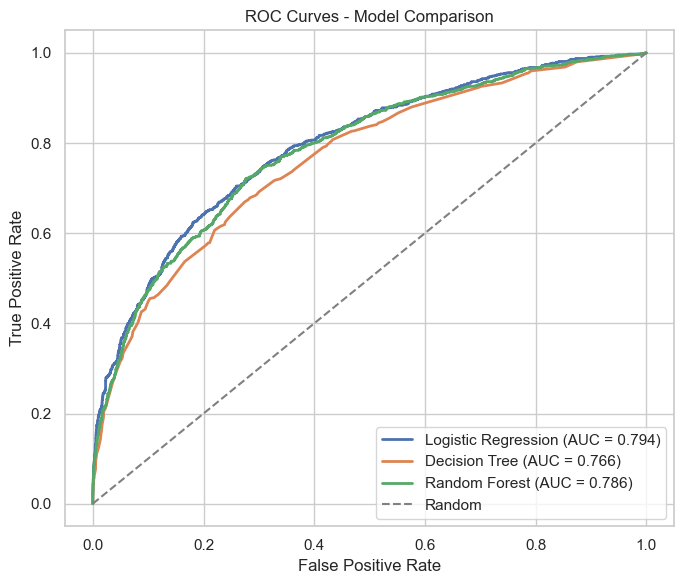

In [12]:
# ROC Curves
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, _, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison'); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

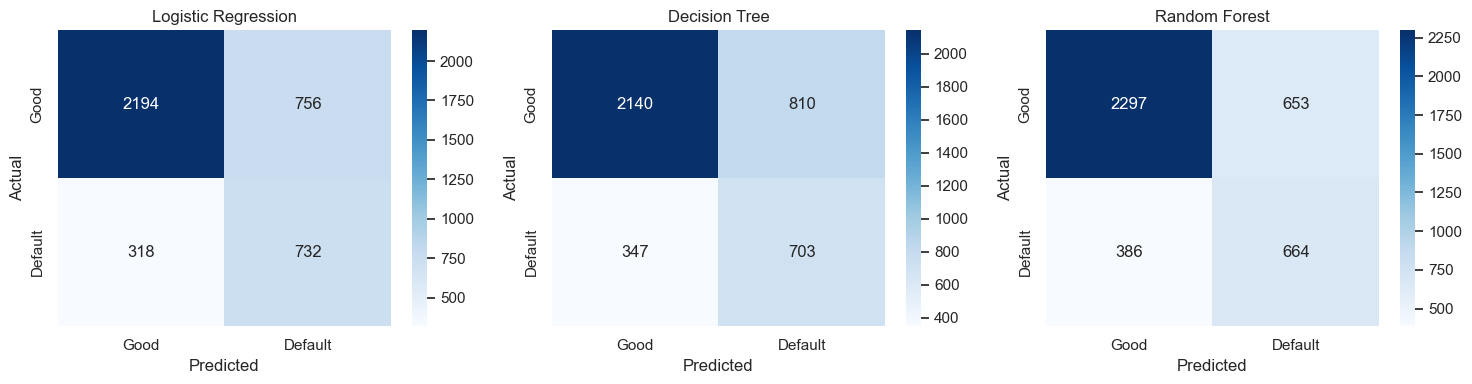

In [13]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Good', 'Default'], yticklabels=['Good', 'Default'])
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

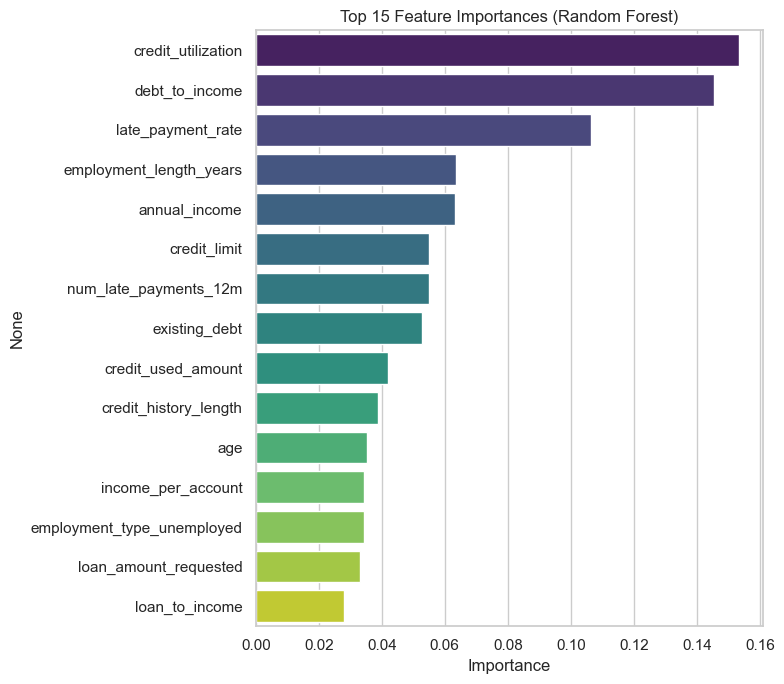

In [14]:
# Feature Importance (Random Forest)
importances = pd.Series(models['Random Forest'].feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 7))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Top 15 Feature Importances (Random Forest)'); plt.xlabel('Importance')
plt.tight_layout(); plt.show()

## 9. Model Selection

We select the best model by **ROC-AUC** — it's the most informative metric for credit scoring because it measures how well the model separates high-risk from low-risk applicants across *all* decision thresholds, not just one fixed cutoff.

In [15]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f'Best model: {best_model_name} (ROC-AUC = {results_df.iloc[0]["ROC-AUC"]:.4f})')

Best model: Logistic Regression (ROC-AUC = 0.7939)


## 10. Save Predictions

Export row-level predictions (actual vs. predicted vs. probability) for the full test set.

In [16]:
predictions_df = X_test.copy()
predictions_df['actual_default'] = y_test.values
predictions_df['predicted_default'] = best_model.predict(X_test_s)
predictions_df['predicted_probability'] = best_model.predict_proba(X_test_s)[:, 1].round(4)

import os
os.makedirs('../results', exist_ok=True)
predictions_df.to_csv('../results/predictions.csv', index=False)
results_df.to_csv('../results/model_comparison_results.csv', index=False)

predictions_df[['actual_default', 'predicted_default', 'predicted_probability']].head(10)

,actual_default,predicted_default,predicted_probability
17985,1,0,0.1840
17750,1,1,0.6173
9096,0,0,0.2668
14447,0,1,0.5549
15318,0,0,0.3306
9871,1,0,0.4490
12747,1,1,0.7270
5203,1,1,0.6454
14246,0,0,0.1606
1771,0,0,0.2634


## 11. Save the Trained Model

Persist the best model + scaler + feature list so it can be reused without retraining.

In [17]:
import joblib
os.makedirs('../models', exist_ok=True)
joblib.dump(
    {'model': best_model, 'scaler': scaler, 'feature_columns': list(X.columns), 'model_name': best_model_name},
    '../models/best_model.pkl',
)
print('Saved to ../models/best_model.pkl')

Saved to ../models/best_model.pkl


## 12. Predict a New Applicant

A small helper function to score a brand-new applicant using the saved model.

In [18]:
def predict_new_applicant(applicant_dict, model=best_model, scaler=scaler, feature_columns=list(X.columns)):
    df_one = pd.DataFrame([applicant_dict])
    df_one['default'] = 0
    df_one = engineer_features(df_one).drop(columns=['default'])
    for col in feature_columns:
        if col not in df_one.columns:
            df_one[col] = 0
    df_one = df_one[feature_columns]
    df_one_scaled = pd.DataFrame(scaler.transform(df_one), columns=feature_columns)
    pred_class = model.predict(df_one_scaled)[0]
    pred_proba = model.predict_proba(df_one_scaled)[0, 1]
    return pred_class, round(pred_proba, 4)

sample_applicant = {
    'age': 29, 'annual_income': 42000, 'employment_length_years': 3,
    'credit_history_length': 6, 'num_open_accounts': 5,
    'credit_limit': 9000, 'credit_utilization': 0.78,
    'existing_debt': 11000, 'num_late_payments_12m': 2,
    'num_credit_inquiries_6m': 3, 'loan_amount_requested': 8000,
    'education': 'bachelors', 'marital_status': 'single',
    'employment_type': 'salaried', 'home_ownership': 'RENT',
    'purpose': 'credit_card',
}

pred_class, pred_proba = predict_new_applicant(sample_applicant)
print('Predicted class:', 'DEFAULT RISK' if pred_class == 1 else 'GOOD CREDIT')
print(f'Default probability: {pred_proba:.2%}')

Predicted class: DEFAULT RISK
Default probability: 91.75%


## 13. Conclusion

- All three models were trained and evaluated on the same held-out test set using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- **Logistic Regression** achieved the highest ROC-AUC, making it the selected model — though Random Forest was close behind with slightly better raw accuracy.
- The top predictive features were credit utilization, debt-to-income ratio, and late payment history — consistent with real-world credit risk drivers.
- The trained model and preprocessing pipeline are saved to `../models/best_model.pkl` for reuse in a scoring application.